# LH Nautical — Data Analysis Project

In [1788]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import duckdb

## Questão 1 - EDA

### Caminho base do projeto

In [1789]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


Carregando os dados em um dataframe Pandas para melhor visulização. 

In [1790]:
DATA_PATH = BASE_PATH / "data"
RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"

In [1791]:
df_vendas = pd.read_csv(RAW_PATH / "vendas_2023_2024.csv", encoding="utf-8")

Parte 1 - Visão geral do dataset

In [1792]:
conn = sqlite3.connect(':memory:')

In [1793]:
df_vendas.to_sql('vendas', conn, index=False, if_exists='replace')

9895

Quantidade total de linhas

In [1794]:
query = """
SELECT COUNT(*) AS total_linhas
FROM vendas
"""

pd.read_sql(query, conn)

,total_linhas
0,9895


Quantidade total de colunas

In [1795]:
query = """
SELECT COUNT(*) AS total_colunas
FROM pragma_table_info('vendas')
"""

pd.read_sql(query, conn)

,total_colunas
0,6


Intervalo d e datas analisado (data mínima e
máxima)

In [1796]:
df_vendas.columns

Index(['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date'], dtype='str')

In [1797]:
query = """
SELECT 
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max
FROM vendas
"""

pd.read_sql(query, conn)

,data_min,data_max
0,01-01-2023,31-12-2024


 Questão 1.1 - SQL
Código calculando:
• Quantidade total d e linhas
• Quantidade total de colunas
• Intervalo de datas analisado (data mínima e máxima)
• Valor mínimo
• Valor máximo
• Valor médio

Query resposta:

In [1798]:
"""
SELECT 
    COUNT(*) AS total_linhas,
    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max,
    MIN(total) AS valor_min,
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio
FROM vendas
"""


"\nSELECT \n    COUNT(*) AS total_linhas,\n    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,\n    MIN(sale_date) AS data_min,\n    MAX(sale_date) AS data_max,\n    MIN(total) AS valor_min,\n    MAX(total) AS valor_max,\n    AVG(total) AS valor_medio\nFROM vendas\n"

In [1799]:
query = """
SELECT 
    COUNT(*) AS total_linhas,
    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max,
    MIN(total) AS valor_min,
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio
FROM vendas
"""

pd.read_sql(query, conn)

,total_linhas,total_colunas,data_min,data_max,valor_min,valor_max,valor_medio
0,9895,6,01-01-2023,31-12-2024,294.5,2222973.0,263797.828267


Questão 1.2 - Validação
Qual é o valor máximo registrado na coluna "total"?

In [1800]:
query = """
SELECT MAX(total) AS valor_maximo
FROM vendas;
"""
pd.read_sql(query, conn)

,valor_maximo
0,2222973.0


Questão 1.3 - Interpretação
Com base na análise exploratória real

In [1801]:
df_vendas['total'].describe()

count    9.895000e+03
mean     2.637978e+05
std      3.900072e+05
min      2.945000e+02
25%      2.313820e+04
50%      8.222500e+04
75%      3.390945e+05
max      2.222973e+06
Name: total, dtype: float64

In [1802]:
df_vendas.isnull().sum()

id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

In [1803]:
df_vendas.duplicated().sum()

np.int64(0)

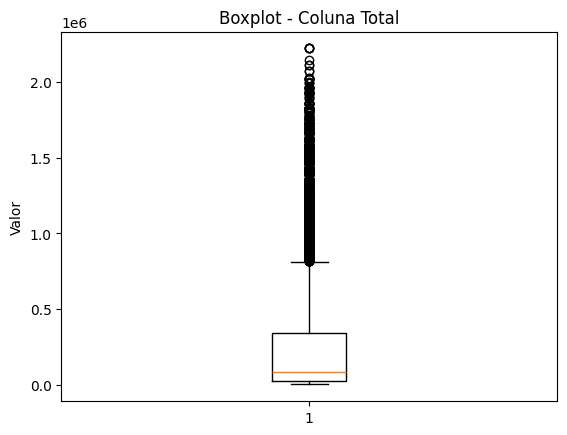

In [1804]:


plt.figure()
plt.boxplot(df_vendas['total'])
plt.title('Boxplot - Coluna Total')
plt.ylabel('Valor')
plt.show()

O dataset tem um intervalo consistente de datas dos anos de 2023 a 2024 em estrutura simples, colunas bem definidas, e isso facilita a análise inicial.
Mas, aparentemente pode haver outliers na coluna "total", já que o valor máximo 2.222.973 é muito superior à média, que é de mais ou menos 263.798, isso mosta grande dispersão nos dados. E indica issopossíveis inconsistências que devem ser investigadas.
Não encontrei problemas estruturais na qualidade dos dados, como ausência de colunas ou falhas de leitura.

### Parte 2 - Análise de valores numéricos

## Questão 2 - Produtos

In [1805]:
df_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")

Parte 1 - Padronize os nomes das categorias d e
produtos em: eletrônicos, propulsão e ancoragem.

In [1806]:
df_produtos.shape

(157, 4)

In [1807]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   name             157 non-null    str  
 1   price            157 non-null    str  
 2   code             157 non-null    int64
 3   actual_category  157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


In [1808]:
df_produtos["actual_category"].unique()

<StringArray>
[          'ELETRONICOS', 'E L E T R Ô N I C O S',           'Eletrunicos',
           'Eletronicoz',           'eLeTrÔnIcOs',           'eletrônicos',
           'Eletrônicos',          'Eletroniscos',           'Eletronicos',
           'eletronicos',           'EletrônicoS',           'ELEtRÔNICOS',
             'PROPULSAO',             'Propulção',                  'Prop',
            'Propulssão',             'propulsao',     'P R O P U L S Ã O',
              'Propução',             'propulsão',             'pRoPuLsÃo',
             'Propulçao',             'Propulsam',             'PrOpUlSãO',
             'Ancoragem',             'AnCoRaGeM',             'Encoragem',
            'Ancoraguem',              'Ancorajm',             'AncorageM',
     'A N C O R A G E M',             'ANCORAGEM',             'aNcOrAgEm',
             'Ancorajem',              'Encoragi',             'ancoragem',
             'Ancorajen',             'AncorajeM',             'Ancoragen'

In [1809]:
df_produtos["actual_category_clean"] = (
    df_produtos["actual_category"]
    .str.lower()
    .str.strip()
)

df_produtos["actual_category_clean"].unique()

<StringArray>
[          'eletronicos', 'e l e t r ô n i c o s',           'eletrunicos',
           'eletronicoz',           'eletrônicos',          'eletroniscos',
             'propulsao',             'propulção',                  'prop',
            'propulssão',     'p r o p u l s ã o',              'propução',
             'propulsão',             'propulçao',             'propulsam',
             'ancoragem',             'encoragem',            'ancoraguem',
              'ancorajm',     'a n c o r a g e m',             'ancorajem',
              'encoragi',             'ancorajen',             'ancoragen']
Length: 24, dtype: str

In [1810]:
import unicodedata

def remover_acentos(texto):
    if isinstance(texto, str):
        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

df_produtos["actual_category_clean"] = df_produtos["actual_category_clean"].apply(remover_acentos)

df_produtos["actual_category_clean"].unique()

<StringArray>
[          'eletronicos', 'e l e t r o n i c o s',           'eletrunicos',
           'eletronicoz',          'eletroniscos',             'propulsao',
             'propulcao',                  'prop',            'propulssao',
     'p r o p u l s a o',              'propucao',             'propulsam',
             'ancoragem',             'encoragem',            'ancoraguem',
              'ancorajm',     'a n c o r a g e m',             'ancorajem',
              'encoragi',             'ancorajen',             'ancoragen']
Length: 21, dtype: str

Remoção de espaços internos nas categorias

In [1811]:
df_produtos["actual_category_clean"] = (
    df_produtos["actual_category_clean"]
    .str.replace(" ", "", regex=False)
)

df_produtos["actual_category_clean"].unique()

<StringArray>
[ 'eletronicos',  'eletrunicos',  'eletronicoz', 'eletroniscos',
    'propulsao',    'propulcao',         'prop',   'propulssao',
     'propucao',    'propulsam',    'ancoragem',    'encoragem',
   'ancoraguem',     'ancorajm',    'ancorajem',     'encoragi',
    'ancorajen',    'ancoragen']
Length: 18, dtype: str

Padronização das categorias

In [1812]:
def padronizar_categoria(cat):
    if "eletro" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat:
        return "ancoragem"
    else:
        return "outros"

In [1813]:
df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()

<StringArray>
['eletronicos', 'outros', 'propulsao', 'ancoragem']
Length: 4, dtype: str

In [1814]:
df_produtos[df_produtos["category_final"] == "outros"]["actual_category_clean"].unique()

<StringArray>
['eletrunicos', 'encoragem', 'encoragi']
Length: 3, dtype: str

In [1815]:
def padronizar_categoria(cat):
    if "eletro" in cat or "eletru" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat or "encor" in cat:
        return "ancoragem"
    else:
        return "outros"

In [1816]:
df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()

<StringArray>
['eletronicos', 'propulsao', 'ancoragem']
Length: 3, dtype: str

In [1817]:
df_produtos.head()

,name,price,code,actual_category,actual_category_clean,category_final
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS,eletronicos,eletronicos
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS,eletronicos,eletronicos
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S,eletronicos,eletronicos
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos,eletrunicos,eletronicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz,eletronicoz,eletronicos


In [1818]:
df_produtos = df_produtos[[
    "name",
    "price",
    "code",
    "category_final"
]].rename(columns={
    "name": "nome_produto",
    "price": "preco",
    "code": "codigo_produto",
    "category_final": "categoria"
})

df_produtos

,nome_produto,preco,codigo_produto,categoria
0,Transponder AIS Maré Magnum,R$ 33122.52,1,eletronicos
1,Transponder Furuno Marlin,R$ 13998.15,2,eletronicos
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,eletronicos
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,eletronicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,eletronicos
...,...,...,...,...
152,Corrente Delta Vox Ion,R$ 495.98,146,ancoragem
153,Corrente Danforth Force Leviathan Impulse,R$ 3030.08,147,ancoragem
154,Âncora Delta Force Barracuda Mako,R$ 4785.56,148,ancoragem
155,Cabo de Nylon Bruce Core,R$ 1163.62,149,ancoragem


In [1819]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   nome_produto    157 non-null    str  
 1   preco           157 non-null    str  
 2   codigo_produto  157 non-null    int64
 3   categoria       157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


Parte 2 - Converta os valores para o tipo
numérico.

In [1820]:
df_produtos["preco"] = (
    df_produtos["preco"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .astype(float)
)

In [1821]:
print(df_produtos['preco'].dtype)

float64



Parte 3 - Remova as duplicatas.

verificando os duplicados

In [1822]:
duplicados_antes = df_produtos.duplicated().sum()
df_produtos = df_produtos.drop_duplicates()
duplicados_depois = df_produtos.duplicated().sum()
duplicados_removidos = duplicados_antes - duplicados_depois
duplicados_removidos

np.int64(7)

Removendo os duplicados.

In [1823]:
duplicados_removidos = df_produtos.duplicated().sum()
duplicados_removidos

np.int64(0)

Questão 2.1 - Faça o upload de seu código
Python

Link para o arquivo questao_2.1.py :

In [1824]:
print(f"SCRIPT PATH: {BASE_PATH / 'questao_2.1.py'}")

SCRIPT PATH: /Users/richardgomes/lh-nautical-data-project/questao_2.1.py


In [1825]:
# Código do arquivo questao_2.1.py

"""
# Questão 2 - Produtos

import pandas as pd
from pathlib import Path
import unicodedata

BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

DATA_PATH = BASE_PATH / "data"
RAW_PATH = DATA_PATH / "raw"

print(f"RAW PATH: {RAW_PATH}")


df_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")


# Parte 1 - Padronize os nomes das categorias d e produtos em: eletrônicos, propulsão e ancoragem.

df_produtos.shape

df_produtos.info()

df_produtos["actual_category"].unique()

df_produtos["actual_category_clean"] = (
    df_produtos["actual_category"]
    .str.lower()
    .str.strip()
)

df_produtos["actual_category_clean"].unique()

import unicodedata

def remover_acentos(texto):
    if isinstance(texto, str):
        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

df_produtos["actual_category_clean"] = df_produtos["actual_category_clean"].apply(remover_acentos)

df_produtos["actual_category_clean"].unique()

# Remoção de espaços internos nas categorias


df_produtos["actual_category_clean"] = (
    df_produtos["actual_category_clean"]
    .str.replace(" ", "", regex=False)
)

df_produtos["actual_category_clean"].unique()

# Padronização das categorias

def padronizar_categoria(cat):
    if "eletro" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat:
        return "ancoragem"
    else:
        return "outros"

df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()


df_produtos[df_produtos["category_final"] == "outros"]["actual_category_clean"].unique()


def padronizar_categoria(cat):
    if "eletro" in cat or "eletru" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat or "encor" in cat:
        return "ancoragem"
    else:
        return "outros"


df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()


df_produtos = df_produtos[[
    "name",
    "price",
    "code",
    "category_final"
]].rename(columns={
    "name": "nome_produto",
    "price": "preco",
    "code": "codigo_produto",
    "category_final": "categoria"
})

df_produtos

df_produtos.info()


# Parte 2 - Converta os valores para o tipo numérico.


df_produtos["preco"] = (
    df_produtos["preco"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df_produtos['preco'].dtype)


# Parte 3 - Remova as duplicatas.

# verificando os duplicados


duplicados_antes = df_produtos.duplicated().sum()
df_produtos = df_produtos.drop_duplicates()
duplicados_depois = df_produtos.duplicated().sum()
duplicados_removidos = duplicados_antes - duplicados_depois
duplicados_removidos

# Removendo os duplicados.

duplicados_removidos = df_produtos.duplicated().sum()
duplicados_removidos

"""

'\n# Questão 2 - Produtos\n\nimport pandas as pd\nfrom pathlib import Path\nimport unicodedata\n\nBASE_PATH = Path().resolve()\n\nwhile BASE_PATH.name != "lh-nautical-data-project":\n    BASE_PATH = BASE_PATH.parent\n\nprint(f"BASE PATH: {BASE_PATH}")\n\nDATA_PATH = BASE_PATH / "data"\nRAW_PATH = DATA_PATH / "raw"\n\nprint(f"RAW PATH: {RAW_PATH}")\n\n\ndf_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")\n\n\n# Parte 1 - Padronize os nomes das categorias d e produtos em: eletrônicos, propulsão e ancoragem.\n\ndf_produtos.shape\n\ndf_produtos.info()\n\ndf_produtos["actual_category"].unique()\n\ndf_produtos["actual_category_clean"] = (\n    df_produtos["actual_category"]\n    .str.lower()\n    .str.strip()\n)\n\ndf_produtos["actual_category_clean"].unique()\n\nimport unicodedata\n\ndef remover_acentos(texto):\n    if isinstance(texto, str):\n        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")\n    return texto\n\ndf_produtos

Questão 2.2 - Validação
Quantos produtos duplicados foram removidos? = 7

## Questão 3 - Custos de Importação

Leitura e carregamento dos dados dos custos de importação (custos_importacao.json)

In [1826]:
with open(RAW_PATH / "custos_importacao.json", "r", encoding="utf-8") as f:
    custos_importacao_json = json.load(f)

In [1827]:
custos_importacao = pd.json_normalize(custos_importacao_json)

In [1828]:
custos_importacao.shape

(150, 4)

In [1829]:
custos_importacao.head(10)

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."
5,6,Transponder AIS Vector,eletrônicos,"[{'start_date': '23/07/2020', 'usd_price': 228..."
6,7,Radar AIS Zen,eletrônicos,"[{'start_date': '26/10/2016', 'usd_price': 625..."
7,8,GPS AIS Zen,eletrônicos,"[{'start_date': '06/12/2019', 'usd_price': 119..."
8,9,Transponder AIS Titan Pulse,eletrônicos,"[{'start_date': '26/12/2018', 'usd_price': 101..."
9,10,Piloto Automático Simrad Titan Flux Magnum,eletrônicos,"[{'start_date': '29/05/2018', 'usd_price': 859..."


Compreendendo o conteúdo de "historic_data"

In [1830]:
custos_importacao["historic_data"].iloc[0]

[{'start_date': '10/08/2016', 'usd_price': 10583.63},
 {'start_date': '15/06/2018', 'usd_price': 8778.36},
 {'start_date': '25/09/2018', 'usd_price': 8023.87},
 {'start_date': '19/03/2019', 'usd_price': 8772.78},
 {'start_date': '17/01/2020', 'usd_price': 7918.18},
 {'start_date': '17/06/2020', 'usd_price': 6310.01},
 {'start_date': '02/07/2021', 'usd_price': 6586.7},
 {'start_date': '16/05/2022', 'usd_price': 6538.2},
 {'start_date': '28/02/2023', 'usd_price': 6360.91},
 {'start_date': '17/10/2023', 'usd_price': 6574.8},
 {'start_date': '16/02/2024', 'usd_price': 6657.12},
 {'start_date': '22/02/2024', 'usd_price': 6703.2},
 {'start_date': '15/03/2024', 'usd_price': 6633.66},
 {'start_date': '02/08/2024', 'usd_price': 5774.5},
 {'start_date': '08/04/2025', 'usd_price': 5579.75}]

Várias datas para apenas um único produto.
Vai ser preciso "explodir" a coluna

In [1831]:
custos_importacao_exploded = custos_importacao.explode("historic_data")

custos_importacao_exploded.head()

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '10/08/2016', 'usd_price': 1058..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '15/06/2018', 'usd_price': 8778..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '25/09/2018', 'usd_price': 8023..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '19/03/2019', 'usd_price': 8772..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/01/2020', 'usd_price': 7918..."


Agora já dá pra separar em colunas, extraindo os campos do dicionário.

In [1832]:
custos_importacao_exploded["start_date"] = custos_importacao_exploded["historic_data"].apply(lambda x: x["start_date"])

custos_importacao_exploded["usd_price"] = custos_importacao_exploded["historic_data"].apply(lambda x: x["usd_price"])

custos_importacao_exploded.head()

,product_id,product_name,category,historic_data,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '10/08/2016', 'usd_price': 1058...",10/08/2016,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '15/06/2018', 'usd_price': 8778...",15/06/2018,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '25/09/2018', 'usd_price': 8023...",25/09/2018,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '19/03/2019', 'usd_price': 8772...",19/03/2019,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/01/2020', 'usd_price': 7918...",17/01/2020,7918.18


Agora posso montar as colunas  finais para como foi pedido. 

In [1833]:
custos_importacao_final = custos_importacao_exploded[[
    "product_id",
    "product_name",
    "category",
    "start_date",
    "usd_price"
]]

custos_importacao_final.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,25/09/2018,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,19/03/2019,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,17/01/2020,7918.18


In [1834]:
custos_importacao_final.info()

<class 'pandas.DataFrame'>
Index: 1260 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1260 non-null   int64  
 1   product_name  1260 non-null   str    
 2   category      1260 non-null   str    
 3   start_date    1260 non-null   str    
 4   usd_price     1260 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 59.1 KB


Tive que corrigir o tipo da data de "start_date"

In [1835]:
custos_importacao_final["start_date"] = pd.to_datetime(
    custos_importacao_final["start_date"],
    dayfirst=True
)

In [1836]:
custos_importacao_final.info()

<class 'pandas.DataFrame'>
Index: 1260 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    1260 non-null   int64         
 1   product_name  1260 non-null   str           
 2   category      1260 non-null   str           
 3   start_date    1260 non-null   datetime64[us]
 4   usd_price     1260 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 59.1 KB


In [1837]:
custos_importacao_final.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,7918.18


Questão 3.1 - Faça o upload de seu código Python


Link para o arquivo questao_3.1.py :

In [1838]:
print(f"SCRIPT PATH: {BASE_PATH / 'questao_3.1.py'}")

SCRIPT PATH: /Users/richardgomes/lh-nautical-data-project/questao_3.1.py


Questão 3.2 - Validação
Quantas entradas de importação o CSV recebeu ao todo
após a normalização? = 

In [1839]:
len(custos_importacao_final)

1260

## Questão 4 - Dados Públicos

Dados públicos do Olinda, sistema de APIs públicas do Banco Central

"A Plataforma Olinda é o módulo de regulação digital do Banco Central do Brasil"

Tive que colocar o periodo que eu precisava na própria URL, não consegui de outra forma

In [1840]:
import pandas as pd
import requests

url = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$top=10000&$format=json"

response = requests.get(url)
data = response.json()

cambio = pd.DataFrame(data['value'])

cambio['data'] = pd.to_datetime(cambio['dataHoraCotacao']).dt.date
cambio['taxa_cambio'] = cambio['cotacaoVenda']

cambio = cambio[['data', 'taxa_cambio']]
cambio = cambio.sort_values('data').drop_duplicates('data', keep='last')

cambio.head()

,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


Criar calendário completo + preencher com último valor conhecido

In [1841]:
calendario = pd.DataFrame({
    'data': pd.date_range(
        start=cambio['data'].min(),
        end=cambio['data'].max()
    )
})

cambio['data'] = pd.to_datetime(cambio['data'])
cambio_completo = calendario.merge(cambio, on='data', how='left')
cambio_completo['taxa_cambio'] = cambio_completo['taxa_cambio'].ffill()

cambio_completo.head(10)

,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855
5,2023-01-07,5.2855
6,2023-01-08,5.2855
7,2023-01-09,5.2967
8,2023-01-10,5.2395
9,2023-01-11,5.2020


Salvei a tabela para garantir acesso mais fácil

In [1842]:
cambio_completo.to_csv(STAGING_PATH /"cambio_diario.csv", index=False)

Parte 1 - Cálculo e modelagem

Preparação para a query em SQL

In [1843]:
conn = sqlite3.connect(":memory:")

pd.read_csv("../data/staging/stg_vendas.csv").to_sql("stg_vendas", conn, index=False, if_exists="replace")
pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv").to_sql("stg_custos", conn, index=False, if_exists="replace")
pd.read_csv("../data/staging/cambio_diario.csv").to_sql("cambio", conn, index=False, if_exists="replace")

730

Conferindo a granularidade dos dados

Para stg_vendas.csv

In [1844]:
query = """
SELECT 
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id_venda) AS vendas_unicas
FROM stg_vendas
"""
base_vendas = pd.read_sql_query(query, conn)
base_vendas.head()

,total_linhas,vendas_unicas
0,9895,9895


E para cambio_diario.csv

In [1845]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT data) AS datas_unicas
FROM cambio
"""

pd.read_sql_query(query, conn)

,total_linhas,datas_unicas
0,730,730


Para stg_custos_importacao_tratado.csv

In [1846]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id_produto) AS produtos_unicos
FROM stg_custos
"""

pd.read_sql_query(query, conn)

,total_linhas,produtos_unicos
0,1260,150


Optei por usar o usar custo mais recente por produto

Parte 1 - Cálculo e modelagem
• Calcule o custo total e m BRL por transação
• Identifique transações com prejuízo
• Agregue os dados por id_produto, gerando:
1. Receita total (BRL)
2. Prejuízo total (BRL)
3. Percentual de perda (prejuízo_total /
receita_total)

In [1847]:
query = """
WITH custos_recentes AS (
    SELECT
        id_produto,
        preco_usd
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_produto
                   ORDER BY data_inicio DESC
               ) as rn
        FROM stg_custos
    )
    WHERE rn = 1
)

SELECT
    v.id_produto,
    SUM(v.valor_total) AS receita_total,
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) AS prejuizo_total,
    
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo

FROM stg_vendas v

LEFT JOIN custos_recentes c
    ON v.id_produto = c.id_produto

LEFT JOIN cambio tc
    ON v.data_venda = tc.data

GROUP BY v.id_produto
"""

resultado = pd.read_sql_query(query, conn)

resultado.head()

,id_produto,receita_total,prejuizo_total,percentual_prejuizo
0,1,17187280.35,154.709200,0.000009
1,2,8862231.15,21.358768,0.000002
2,3,4322136.25,2318.092263,0.000536
3,4,1915160.00,29.978055,0.000016
4,5,13494880.35,1091.034870,0.000081


In [1848]:
resultado.to_csv("../data/staging/indicadores_financeiros_produtos.csv", index=False)

Parte 2 - Análise visual

In [1849]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df_produtos = pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv")
df_produtos = df_produtos[["id_produto", "nome_produto"]].drop_duplicates()
df = df.merge(df_produtos, on="id_produto", how="left")

In [1850]:
df["produto_label"] = df["nome_produto"] + " (ID " + df["id_produto"].astype(str) + ")"

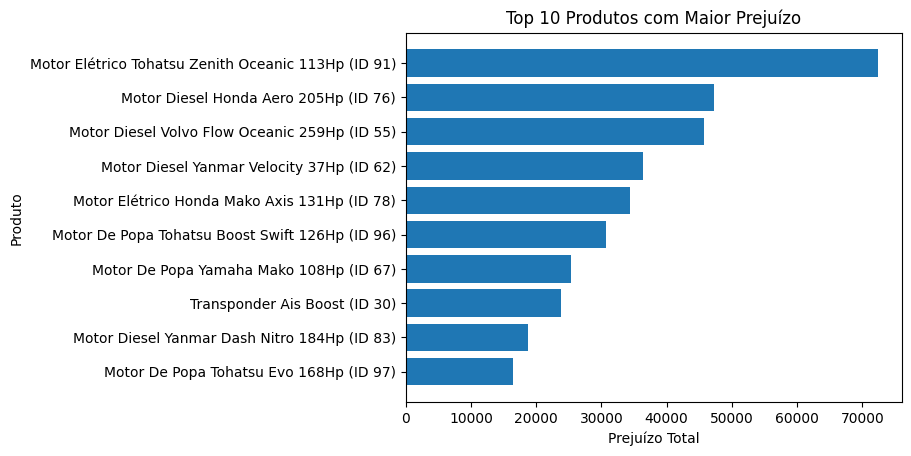

In [1851]:
top10 = df.sort_values("prejuizo_total", ascending=False).head(10)

plt.figure()
plt.barh(top10["produto_label"], top10["prejuizo_total"])
plt.title("Top 10 Produtos com Maior Prejuízo")
plt.xlabel("Prejuízo Total")
plt.ylabel("Produto")
plt.gca().invert_yaxis()

plt.show()

Parte 3 - Análise objetiva Responda

In [1852]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")

In [1853]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df_produtos = pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv")
df_produtos = df_produtos[["id_produto", "nome_produto"]].drop_duplicates()
df = df.merge(df_produtos, on="id_produto", how="left")

In [1854]:
maior_prejuizo = df.loc[[df["prejuizo_total"].idxmax()]]
maior_prejuizo[["id_produto", "nome_produto", "prejuizo_total"]]

,id_produto,nome_produto,prejuizo_total
90,91,Motor Elétrico Tohatsu Zenith Oceanic 113Hp,72420.727535


In [1855]:
maior_percentual = df.loc[[df["percentual_prejuizo"].idxmax()]]
maior_percentual[["id_produto", "nome_produto", "percentual_prejuizo"]]

,id_produto,nome_produto,percentual_prejuizo
103,104,Cabo De Nylon Delta Zen Vortex Storm,0.002637


In [1856]:
produto_abs = maior_prejuizo["id_produto"].values[0]
produto_pct = maior_percentual["id_produto"].values[0]

nome_abs = maior_prejuizo["nome_produto"].values[0]
nome_pct = maior_percentual["nome_produto"].values[0]

mesmo = produto_abs == produto_pct

print(f"Produto com maior prejuízo absoluto: {nome_abs}")

if mesmo:
    print("É o mesmo produto com maior percentual de perda: SIM")
else:
    print("É o mesmo produto com maior percentual de perda: NÃO")
    print(f"Produto com maior percentual de perda: {nome_pct}")

Produto com maior prejuízo absoluto: Motor Elétrico Tohatsu Zenith Oceanic 113Hp
É o mesmo produto com maior percentual de perda: NÃO
Produto com maior percentual de perda: Cabo De Nylon Delta Zen Vortex Storm


Questão 4.1 - Código SQL

In [1857]:
"""
WITH custos_recentes AS (
    SELECT
        id_produto,
        preco_usd
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_produto
                   ORDER BY data_inicio DESC
               ) as rn
        FROM stg_custos
    )
    WHERE rn = 1
)

SELECT
    v.id_produto,
    SUM(v.valor_total) AS receita_total,
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) AS prejuizo_total,
    
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo

FROM stg_vendas v

LEFT JOIN custos_recentes c
    ON v.id_produto = c.id_produto

LEFT JOIN cambio tc
    ON v.data_venda = tc.data

GROUP BY v.id_produto
"""

'\nWITH custos_recentes AS (\n    SELECT\n        id_produto,\n        preco_usd\n    FROM (\n        SELECT *,\n               ROW_NUMBER() OVER (\n                   PARTITION BY id_produto\n                   ORDER BY data_inicio DESC\n               ) as rn\n        FROM stg_custos\n    )\n    WHERE rn = 1\n)\n\nSELECT\n    v.id_produto,\n    SUM(v.valor_total) AS receita_total,\n    SUM(\n        CASE \n            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 \n            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)\n            ELSE 0\n        END\n    ) AS prejuizo_total,\n\n    SUM(\n        CASE \n            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 \n            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)\n            ELSE 0\n        END\n    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo\n\nFROM stg_vendas v\n\nLEFT JOIN custos_recentes c\n    ON v.id_produto = c.id_produto\n\nLEFT JOIN cambio tc\n    ON v.data_venda = tc.data\n

Questão 4.2 - Validação.

Qual é o id_produto que apresentou a maior
porcentagem de perda financeira relativa (maior % de
prejuízo sobre sua receita) no período analisado? = 104

In [1858]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df.loc[[df["percentual_prejuizo"].idxmax()]]

,id_produto,receita_total,prejuizo_total,percentual_prejuizo
103,104,1275786.8,3364.342328,0.002637


Questão 4.3 - Interpretação

Qual data de câmbio você utilizou?

Utilizei a taxa de câmbio do dia da venda "data_venda", com um join da tabela de câmbio diário "cambio_diario" usando as datas.

Como definiu o prejuízo?

O prejuízo foi calculado da diferença entre o custo do produto convertido em BRL e o valor total da venda. Quando o custo em BRL (preco_usd * taxa_cambio) foi maior que o valor da venda, a transação teve prejuízo.

Alguma suposição relevante?

Usei o custo mais recente de cada produto, com base na data de início "data_inicio", para simplificar o modelo.

## Questão 5 - Análise de clientes